In [1]:
%load_ext autoreload
%autoreload 2
    
import warnings
import matplotlib.pyplot as plt
import numpy as np
import glob
import xarray as xr
import gsw
# import regionate
import cartopy.crs as ccrs
# import CM4Xutils #needed to run pip install nc-time-axis
import sys
sys.path.insert(0, '/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/src')
# from src import *
import cartopy.feature as cfeature
import warnings
# from numpy import RankWarning
import cmocean
warnings.filterwarnings('ignore')
import matplotlib as mpl
mpl.rcParams["savefig.facecolor"] = "k"
mpl.rcParams["savefig.edgecolor"] = "k"
mpl.rcParams["savefig.transparent"] = False

In [2]:
from dask.distributed import Client
client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 6
Total threads: 36,Total memory: 160.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:35085,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:46720,Total threads: 6
Dashboard: /proxy/41768/status,Memory: 26.67 GiB
Nanny: tcp://127.0.0.1:42757,


2026-01-14 12:44:32,055 - tornado.application - ERROR - Uncaught exception GET /individual-workers-memory/ws (127.0.0.1)
HTTPServerRequest(protocol='http', host='127.0.0.1:9751', method='GET', uri='/individual-workers-memory/ws', version='HTTP/1.1', remote_ip='127.0.0.1')
Traceback (most recent call last):
  File "/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/tornado/websocket.py", line 965, in _accept_connection
    open_result = handler.open(*handler.open_args, **handler.open_kwargs)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/tornado/web.py", line 3388, in wrapper
    return method(self, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/bokeh/server/views/ws.py", line 149, in open
    raise ProtocolError("Token is e

In [3]:
# GLODAP:model variable naming conventions
model2glodap_names = {'cfc12':'cfc12','cfc11':'cfc11','sf6':'sf6','thetao':'theta','so':'salinity'}
variable_kwargs = {
    'cfc12':{'conversion':1e12/1035,'cmap':'Greens','units':'pmolkg-1'},
    'cfc11':{'conversion':1e12/1035,'cmap':'PuRd','units':'pmolkg-1'},
    'sf6':{'conversion':1e12/1035 * 1e3,'cmap':'PuRd','units':'fmolkg-1'},
    'theta':{'conversion':1,'cmap':cmocean.cm.thermal,'units':'degK','bins':np.arange(-2,35,0.2),'anombins':np.arange(-4,4.05,0.05)},
    'salinity':{'conversion':1,'cmap':cmocean.cm.haline,'units':'psu','bins':np.arange(32,37,0.05),'anombins':np.arange(-1,1.02,0.02)}
}

In [4]:
def get_trend(ds, dim = "year"): 
    # We can fit a polynomial of degree 1 to the monthly anomalies 
    p = ds.polyfit(dim=dim, deg=1, skipna = True)
    
    # Now, apply that polynomial to get the fitted values from the data
    trend = p.polyfit_coefficients.sel(degree = 1)
    trend["geolat"] = ds["geolat"]
    trend["geolon"] = ds["geolon"]

    return trend
    
mean_over_period = lambda ds, time_slice: ds.sel(year = time_slice).mean("year", skipna = True) 
trend_over_period = lambda ds, time_slice: get_trend(ds.sel(year = time_slice), dim = "year")
average_period = lambda ds, time_slice: ds.sel(year = time_slice).mean("year", skipna = True) 

def plot_spatial(a, avg_var, vmin=None, vmax=None, extend = "both", cmap = "bwr"):

        if vmin is None or vmax is None:
            warnings.warn(
                "One or more of vmin, vmax, or levels was not provided. "
                "Automatically calculating all three from the data range."
            )
            vmin = float(avg_var.min())
            vmax = float(avg_var.max())
            n_levels = 21
            levels = np.linspace(vmin, vmax, n_levels)
            levels = np.round(levels, decimals = 2)
        
        cb = a.pcolormesh(avg_var["geolon"], avg_var["geolat"], avg_var.values, 
                                          vmin = vmin, vmax = vmax, 
                                          cmap = cmap,  transform = ccrs.PlateCarree())
        return cb

In [5]:
savedir = "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/"
savename = savedir + f"abyssal_sigma2_depths.nc"
ds = xr.open_mfdataset(savename, engine="h5netcdf", parallel = True)

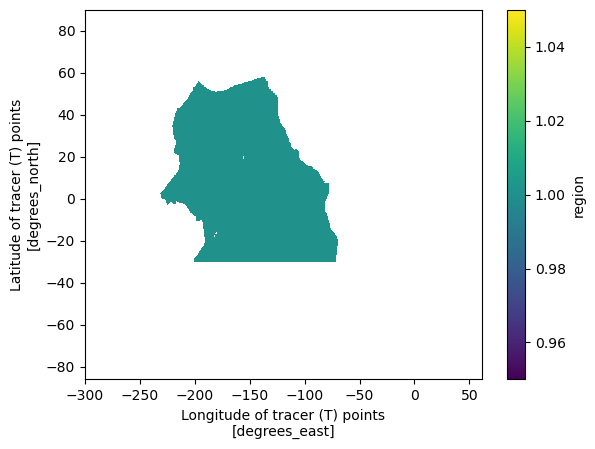

In [6]:
from xmip.preprocessing import combined_preprocessing
import regionmask
from xmip.regionmask import merged_mask

basins = regionmask.defined_regions.natural_earth_v5_1_2.ocean_basins_50
# basins.plot(add_ocean=False, add_label=False)
basin_masks = basins.mask(ds.geolon, ds.geolat)
PAC_mask =  1. * (basin_masks.where((basin_masks == 3) + (basin_masks == 4)) > 0.0)
PAC_mask = PAC_mask.where((PAC_mask > 0) * (ds.wet > 0) * (ds.geolat > -30))
# PAC_mask = PAC_mask.compute()
PAC_mask.plot(x = "geolon", y = "geolat")

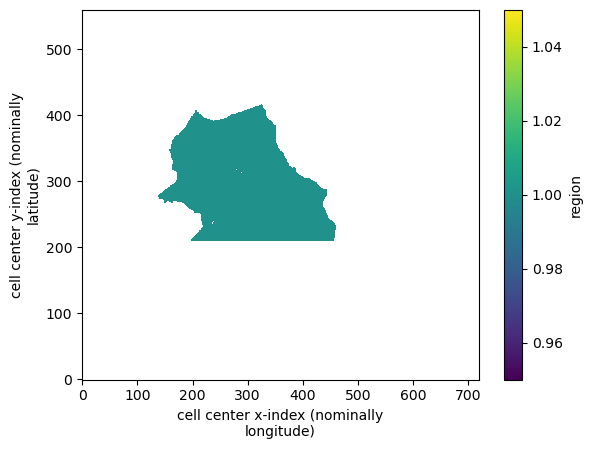

In [7]:
PAC_mask.plot()

In [8]:
area_average = lambda ds, mask: (ds * ds.areacello).where(mask > 0).sum(["xh"], skipna = True) / (ds.areacello).where(mask > 0).sum(["xh"], skipna = True)

In [9]:
sigma = 37.03
ds_bottom =  ds.sel(sigma2 = sigma, method = "nearest").sel(yh = slice(None, 450), xh = slice(100, 500))
    
ds_bottom = ds_bottom.sel(year = slice(1850, 2099)).compute()

ds_bottom_effect = ds_bottom.sel(expt = "forced") - ds_bottom.sel(expt = "control")
ds_bottom_effect = ds_bottom_effect.assign_coords(expt=["effect"])
ds_bottoms = xr.concat([ds_bottom, ds_bottom_effect], dim = "expt")

In [10]:
import warnings

import matplotlib.pyplot as plt
import xarray as xr
from shapely.errors import ShapelyDeprecationWarning
from xmovie import Movie

warnings.filterwarnings(
    action='ignore',
    category=ShapelyDeprecationWarning,  # in cartopy
)
warnings.filterwarnings(
    action="ignore",
    category=UserWarning,
    message=r"No `(vmin|vmax)` provided. Data limits are calculated from input. Depending on the input this can take long. Pass `\1` to avoid this step"
)

%matplotlib inline

In [11]:
area_average = lambda ds, area, mask: (ds * area).where((mask > 0) * (~np.isnan(ds))).sum(["xh", "yh"], skipna = True) / (area).where((mask > 0) * (~np.isnan(ds))).sum(["xh", "yh"], skipna = True)


In [12]:
PAC_ts = area_average(ds_bottoms, ds_bottoms.areacello, PAC_mask)

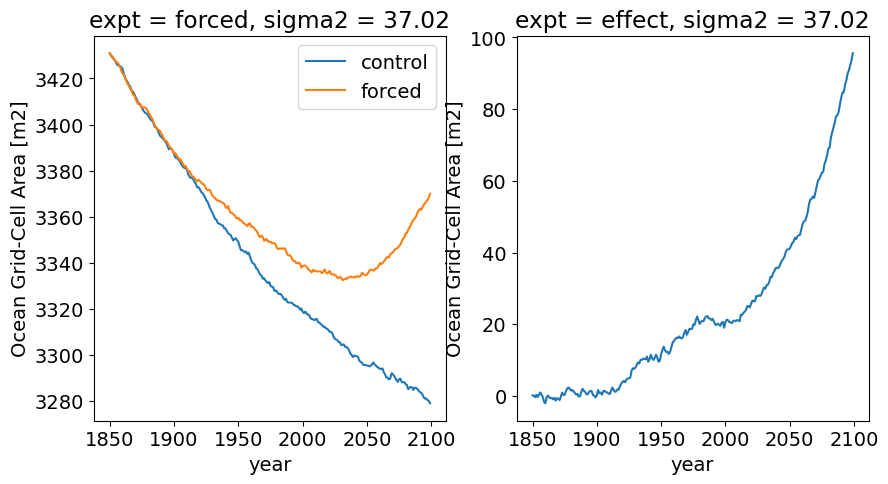

In [13]:
fig, ax = plt.subplots(1, 2, figsize = (10, 5), sharey = False)
PAC_ts.depth.sel(expt = "control").plot(ax = ax[0], label = "control")
PAC_ts.depth.sel(expt = "forced").plot(ax = ax[0], label = "forced")
ax[0].legend()

PAC_ts.depth.sel(expt = "effect").plot(ax = ax[1])
fig.show()

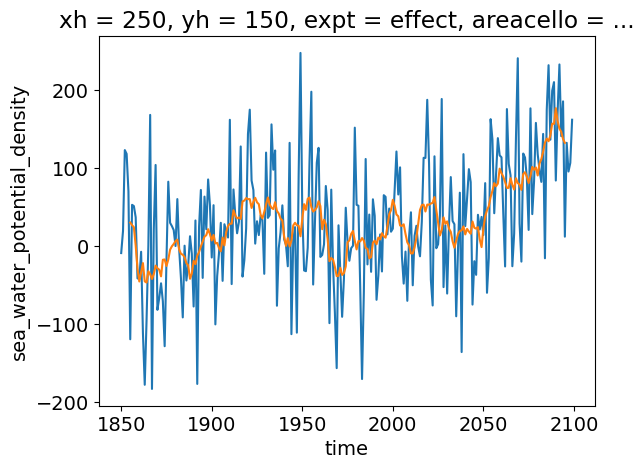

In [14]:
ds_bottom_effect_cropped = ds_bottoms.depth.sel(expt = "effect")
ds_bottom_effect_cropped = ds_bottom_effect_cropped.rename({"year":"time"})

ds_bottom_effect_cropped.isel(xh = 150, yh = 150).plot()

ds_bottom_effect_cropped = ds_bottom_effect_cropped.rolling(time=10, center=True).mean()
# ds_bottom_effect_cropped = ds_bottom_effect_cropped.dropna(dim = "time")
ds_bottom_effect_cropped.isel(xh = 150, yh = 150).plot()

In [15]:
area_average = lambda ds, area, mask: (ds * area).where((mask > 0) * (~np.isnan(ds))).sum(["xh", "yh"], skipna = True) / (area).where((mask > 0) * (~np.isnan(ds))).sum(["xh", "yh"], skipna = True)

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

def custom_plotfunc(ds, fig, tt, *args, **kwargs):
    # Projection of the plotting axes (map projection). Data are assumed lon/lat.
    proj = ccrs.Robinson(central_longitude = 120)
    data_crs = ccrs.PlateCarree()

    ax1, ax2 = fig.subplots(1, 2, sharex=False, sharey=True, subplot_kw={"projection": proj})
    fig.set_figwidth(15)
    fig.set_figheight(5)

    tval = float(ds["time"].isel(time=tt).values)
    fig.suptitle(
        f"Isopycnal Depth (σ = {sigma})   year = {tval:.2f}",
        fontweight="bold",
        y=0.92,
        x = 0.43
    )

    for ax in (ax1, ax2):
        ax.set_facecolor("darkgrey")
        ax.coastlines(linewidth=0.8)
        ax.add_feature(cfeature.LAND, facecolor="0.75", edgecolor="none", zorder=0)

        gl = ax.gridlines(
            crs=data_crs,
            draw_labels=True,
            alpha=0.0,
        )
        gl.top_labels = False
        gl.right_labels = False
        gl.xformatter = LONGITUDE_FORMATTER
        gl.yformatter = LATITUDE_FORMATTER

    ds_forced = ds.sel(expt="forced")
    ds_control = ds.sel(expt="control")

    m1 = ds_control.isel(time=tt).T.plot.contourf(ax=ax1, x="geolon", y="geolat", 
                                                  transform=data_crs,
                                                  levels=15, vmin=ds["vmin"].values, vmax=ds["vmax"].values,
                                                  cmap="Spectral_r",
                                                  add_colorbar=False,
                                                  extend="both")

    m2 = ds_forced.isel(time=tt).T.plot.contourf(ax=ax2, x="geolon", y="geolat", 
                                                 transform=data_crs,
                                                 levels=15, vmin=ds["vmin"].values, vmax=ds["vmax"].values,
                                                 cmap="Spectral_r",
                                                 add_colorbar=False,
                                                 extend="both")

    fig.colorbar(m2, ax=[ax1, ax2], extend="both", label="Depth [m]")

    ax1.set_title("Control")
    ax2.set_title("Historical/SSP585")

    return None, None


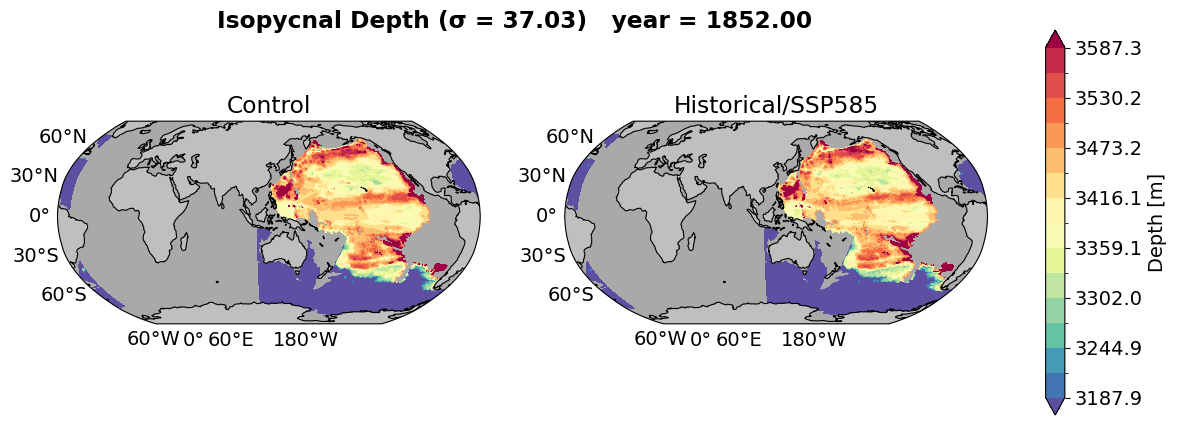

In [16]:
ds_bottom_effect_cropped = 1.0 * ds_bottoms.depth
ds_bottom_effect_cropped = ds_bottom_effect_cropped.rename({"year":"time"})
# ds_bottom_effect_cropped = ds_bottom_effect_cropped.rolling(time=10, center=True).mean()
tmin = ds_bottom_effect_cropped.time.min(); tmax = ds_bottom_effect_cropped.time.max()
# ds_bottom_effect_cropped = ds_bottom_effect_cropped.interp(time = np.arange(tmin,tmax, 0.5))

ds_bottom_effect_cropped["vmax"] = np.abs(ds_bottom_effect_cropped.sel(expt = "forced").where(PAC_mask > 0)).quantile(0.99).compute()
ds_bottom_effect_cropped["vmin"] = np.abs(ds_bottom_effect_cropped.sel(expt = "forced").where(PAC_mask > 0)).quantile(0.01).compute()

    
mov_custom = Movie(ds_bottom_effect_cropped, custom_plotfunc, framerate=1, dpi = 100)
mov_custom.preview(2)

In [ ]:
ds_bottom_effect_cropped = 1.0 * ds_bottoms.depth
ds_bottom_effect_cropped = ds_bottom_effect_cropped.rename({"year":"time"})
# ds_bottom_effect_cropped = ds_bottom_effect_cropped.rolling(time=10, center=True).mean()
tmin = ds_bottom_effect_cropped.time.min(); tmax = ds_bottom_effect_cropped.time.max()
# ds_bottom_effect_cropped = ds_bottom_effect_cropped.interp(time = np.arange(tmin,tmax, 0.5))

ds_bottom_effect_cropped["vmax"] = np.abs(ds_bottom_effect_cropped.sel(expt = "forced").where(PAC_mask > 0)).quantile(0.99).compute()
ds_bottom_effect_cropped["vmin"] = np.abs(ds_bottom_effect_cropped.sel(expt = "forced").where(PAC_mask > 0)).quantile(0.01).compute()

    
mov_custom = Movie(ds_bottom_effect_cropped, custom_plotfunc, framerate=1, dpi = 100)
mov_custom.preview(2)

mov_custom.save("/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/movies/isopycnal_depth_control_v_forced.gif", 
                remove_movie=False, 
                progress=True, 
               overwrite_existing = True)

  0%|          | 0/250 [00:00<?, ?it/s]

In [ ]:
area_average = lambda ds, area, mask: (ds * area).where((mask > 0) * (~np.isnan(ds))).sum(["xh", "yh"], skipna = True) / (area).where((mask > 0) * (~np.isnan(ds))).sum(["xh", "yh"], skipna = True)

def custom_plotfunc_2(ds, fig, tt, *args, **kwargs):
    proj = kwargs.get("projection", ccrs.Robinson(central_longitude=120))
    data_crs = kwargs.get("data_crs", ccrs.PlateCarree())

    ax1 = fig.subplots(1, 1, sharex=False, sharey=True, subplot_kw={"projection": proj})
    fig.set_figwidth(7)
    fig.set_figheight(7)

    tval = float(ds["time"].isel(time=tt).values)
    fig.suptitle(
        f"Isopycnal Depth (σ = {sigma})   year = {tval:.2f}",
        fontweight="bold",
        y=0.99,
    )

    ax1.set_facecolor("darkgrey")
    ax1.coastlines(linewidth=0.8)
    ax1.add_feature(cfeature.LAND, facecolor="0.75", edgecolor="none", zorder=0)

    gl = ax1.gridlines(crs=data_crs, draw_labels=True, alpha=0.0)
    gl.top_labels = False
    gl.right_labels = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER

    ds_eff = ds.sel(expt="effect")

    m = ds_eff.isel(time=tt).plot.contourf(
        ax=ax1,
        x="geolon",
        y="geolat",
        transform=data_crs,
        levels=21,
        vmin=ds["vmin"].values,
        vmax=ds["vmax"].values,
        cmap="Spectral_r",
        add_colorbar=False,
        extend="both",
    )

    fig.colorbar(m, ax=ax1, extend="both", label="Depth [m]")

    ax1.set_title("Effect of External Forcing")

    return None, None

In [ ]:
ds_bottom_effect_cropped = ds_bottoms.depth
ds_bottom_effect_cropped = ds_bottom_effect_cropped.rename({"year":"time"})
ds_bottom_effect_cropped["vmax"] =  np.abs(ds_bottom_effect_cropped.sel(expt = "effect").where(PAC_mask > 0)).quantile(0.90).compute()
ds_bottom_effect_cropped["vmin"] = -ds_bottom_effect_cropped["vmax"]
    
mov_custom = Movie(ds_bottom_effect_cropped, custom_plotfunc_2, framerate=1, dpi = 100)
mov_custom.preview(7)

In [ ]:
ds_bottom_effect_cropped = ds_bottoms.depth
ds_bottom_effect_cropped = ds_bottom_effect_cropped.rename({"year":"time"})
ds_bottom_effect_cropped["vmax"] =  np.abs(ds_bottom_effect_cropped.sel(expt = "effect").where(PAC_mask > 0)).quantile(0.90).compute()
ds_bottom_effect_cropped["vmin"] = -ds_bottom_effect_cropped["vmax"]
    
mov_custom = Movie(ds_bottom_effect_cropped, custom_plotfunc_2, framerate=1, dpi = 100)
mov_custom.preview(7)
mov_custom.save("/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/movies/isopycnal_depth_forced.gif", 
                remove_movie=False, 
                progress=True, 
               overwrite_existing = True)

In [ ]:
ds_bottom_effect_cropped = ds_bottoms.depth
ds_bottom_effect_cropped = ds_bottom_effect_cropped.rename({"year":"time"})
ds_bottom_effect_cropped = ds_bottom_effect_cropped.rolling(time=10, center=True).mean("time")
ds_bottom_effect_cropped["vmax"] =  np.abs(ds_bottom_effect_cropped.sel(expt = "effect").where(PAC_mask > 0)).quantile(0.98).compute()
ds_bottom_effect_cropped["vmin"] = -ds_bottom_effect_cropped["vmax"]
    
mov_custom = Movie(ds_bottom_effect_cropped, custom_plotfunc_2, framerate=1, dpi = 100)
mov_custom.preview(7)
mov_custom.save("/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/movies/isopycnal_depth_forced_rolling.gif", 
                remove_movie=False, 
                progress=True, 
               overwrite_existing = True)